In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/Users/mdnazmulhudanabil/Documents/mfs-fraud-detection/Data/frud_data.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.iloc[df["isFraud"] == 1][:5]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

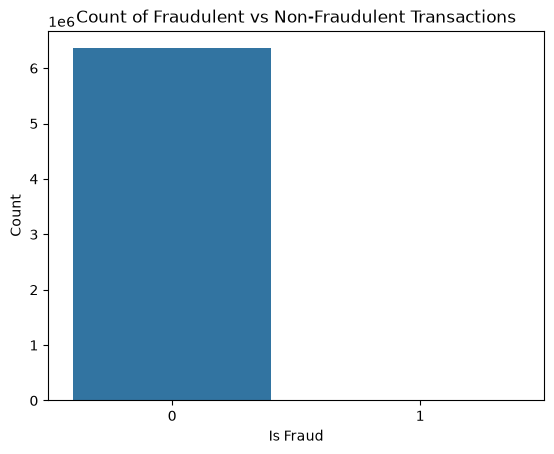

In [11]:
sns.countplot(x="isFraud", data=df)
plt.title("Count of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

In [12]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

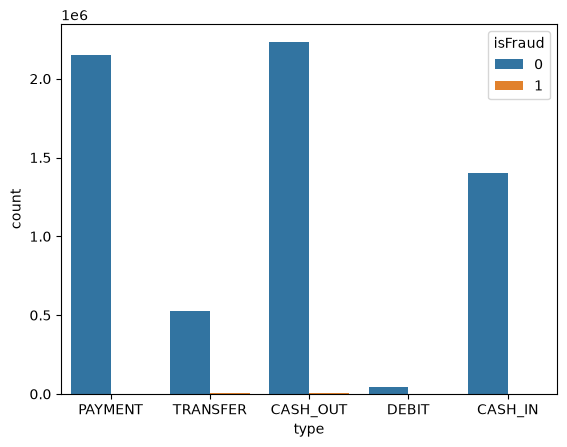

In [13]:
# Type bazında

sns.countplot(data=df, x="type", hue="isFraud")

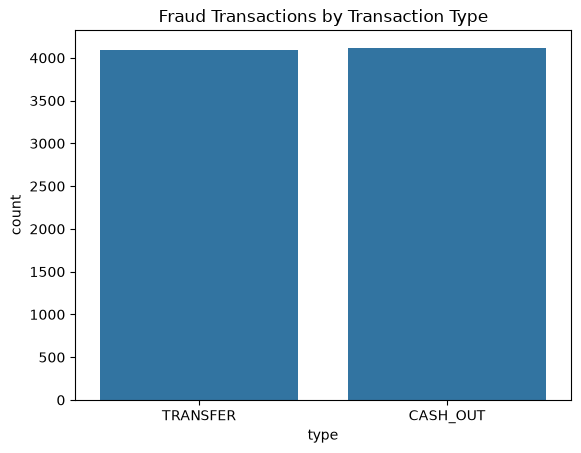

In [14]:
# Oranlar çok uçuk olduğundan sadece isFraud = 1 için bakalım

sns.countplot(
    data=df[df["isFraud"] == 1],
    x="type"
)

plt.title("Fraud Transactions by Transaction Type")
plt.show()


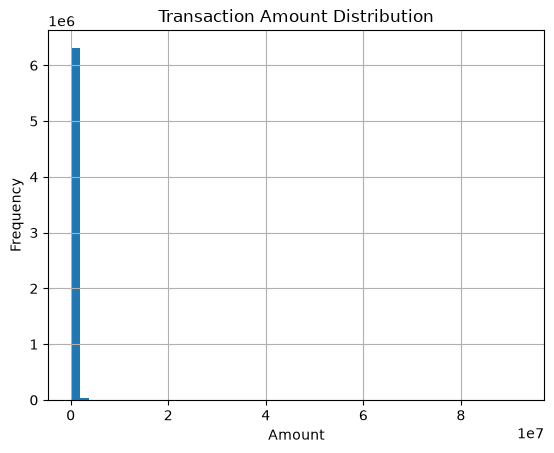

In [15]:
df["amount"].hist(bins=50)

plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.show()

In [16]:
print(df[df["amount"]>0])

         step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1              19384.72  M2044282

In [17]:
pd.crosstab(df["isFlaggedFraud"], df["isFraud"], normalize="index") *100

isFraud,0,1
isFlaggedFraud,,
0,99.871169,0.128831
1,0.000000,100.000000


In [18]:
df[(df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)].shape

(16, 11)

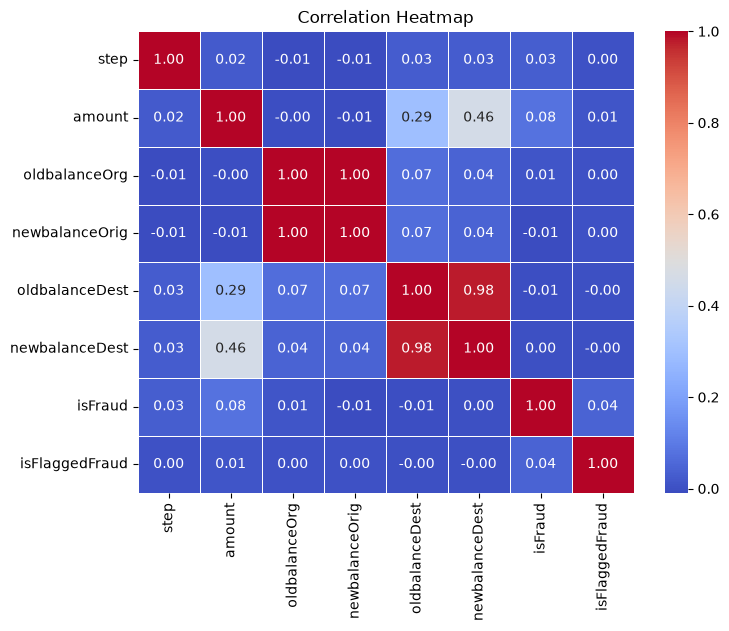

In [19]:
matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


In [21]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
print(fraud_types.shape)

(2770409, 11)


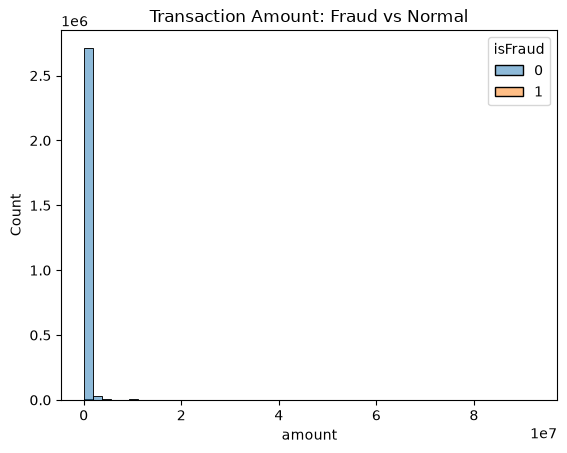

In [22]:
sns.histplot(
    data=fraud_types,
    x="amount",
    hue="isFraud",
    bins=50
)

plt.title("Transaction Amount: Fraud vs Normal")
plt.show()

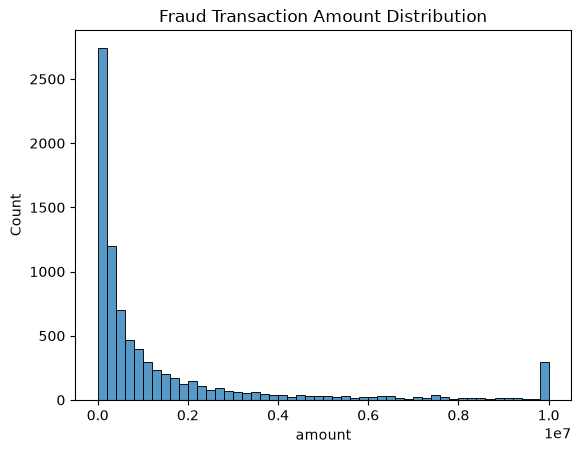

In [23]:
sns.histplot(
    data=fraud_types[fraud_types["isFraud"] == 1],
    x="amount",
    bins=50
)

plt.title("Fraud Transaction Amount Distribution")
plt.show()

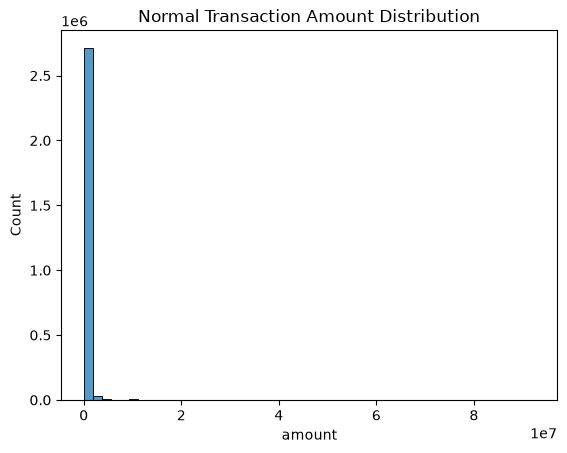

In [24]:
sns.histplot(
    data=fraud_types[fraud_types["isFraud"] == 0],
    x="amount",
    bins=50
)

plt.title("Normal Transaction Amount Distribution")
plt.show()

In [25]:
df["balance_change_org"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

In [26]:
print(df["balance_change_org"])

0             9839.64
1             1864.28
2              181.00
3              181.00
4            11668.14
              ...    
6362615     339682.13
6362616    6311409.28
6362617    6311409.28
6362618     850002.52
6362619     850002.52
Name: balance_change_org, Length: 6362620, dtype: float64


In [27]:
transfer_df = df[df["type"] == "TRANSFER"].copy()

In [28]:
transfer_df.groupby("isFraud")["balance_change_org"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
isFraud,,,
0,528812,3.317839e+04,0.00
1,4097,1.460770e+06,438394.67


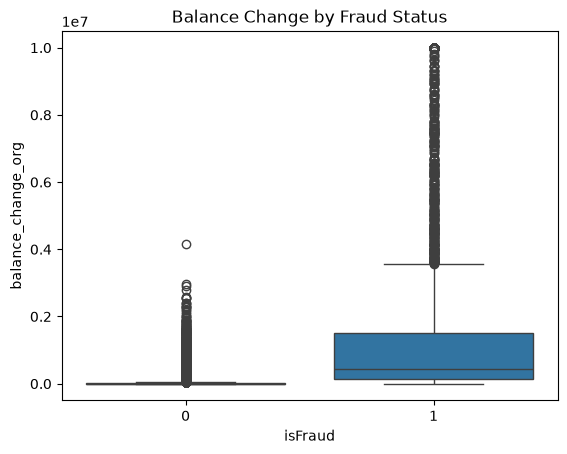

In [29]:
sns.boxplot(
    data=transfer_df,
    x="isFraud",
    y="balance_change_org"
)

plt.title("Balance Change by Fraud Status")
plt.show()

## Feature Engineering

In [30]:
df["balance_error_org"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
)

In [31]:
df["balance_change_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [32]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_change_org,balance_error_org,balance_change_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0.0,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0.0


In [33]:
df["hour"] = df["step"] % 24

## Model Preparation without Feature Engineering

In [34]:
X = df[[
    "step",
    "type",
    "amount"
]]

y = df["isFraud"]

In [35]:
X = pd.get_dummies(X, columns=["type"], drop_first=True)
X.head()

,step,amount,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,False,False,True,False
1,1,1864.28,False,False,True,False
2,1,181.00,False,False,False,True
3,1,181.00,True,False,False,False
4,1,11668.14,False,False,True,False


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # using stratify=y because the proportion of fraud is very low and we want to maintain that ratio
)

In [37]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(5090096, 6)
(1272524, 6)
isFraud
0    5083526
1       6570
Name: count, dtype: int64
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train_scaled[:5]

array([[-1.60457369, -0.28216888, -0.73658127, -0.08096137,  1.39901269,
        -0.30236636],
       [-1.56944154, -0.28724842, -0.73658127, -0.08096137,  1.39901269,
        -0.30236636],
       [-0.08686509,  0.30093765,  1.35762345, -0.08096137, -0.7147898 ,
        -0.30236636],
       [-0.05173294, -0.28686834, -0.73658127, -0.08096137,  1.39901269,
        -0.30236636],
       [-0.70519081,  0.06325744, -0.73658127, -0.08096137, -0.7147898 ,
        -0.30236636]])

In [40]:
# Baseline Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [41]:
y_pred = model.predict(X_test_scaled)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.998693934259786
Recall: 0.0
Precision: 0.0
F1 Score: 0.0


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1270862      19]
 [   1643       0]]


In [44]:
tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 1270862
FP: 19
FN: 1643
TP: 0


In [45]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_proba[:5]

array([0.0070275 , 0.00012538, 0.00010395, 0.00104253, 0.00219835])

In [46]:
print(y_proba.max())

0.9549418161463947


In [47]:
print((y_proba >= 0.5).sum())

19


In [48]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.8962177014932304


In [49]:
threshold = 0.10

y_pred_01 = (y_proba >= threshold).astype(int)

In [50]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_01))
print(classification_report(y_test, y_pred_01))

[[1270769     112]
 [   1633      10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.08      0.01      0.01      1643

    accuracy                           1.00   1272524
   macro avg       0.54      0.50      0.51   1272524
weighted avg       1.00      1.00      1.00   1272524



In [51]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

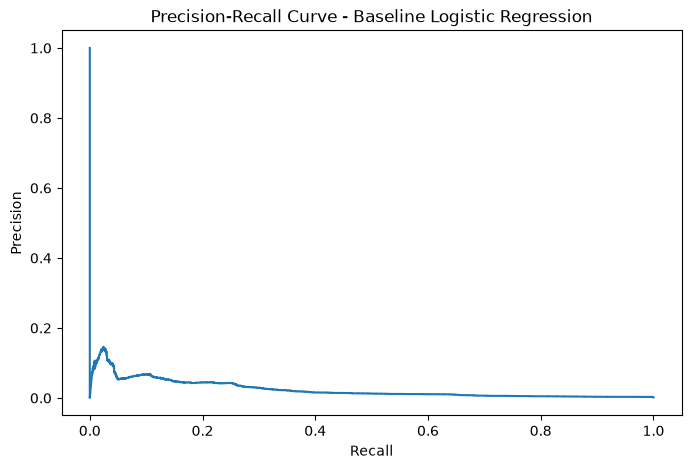

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline Logistic Regression")

plt.show()

### Feature Engineering Model

In [53]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balance_change_org', 'balance_error_org',
       'balance_change_dest', 'hour'],
      dtype='str')

In [54]:
X2 = df[[
    "step",
    "type",
    "amount",
    "balance_change_org",
    "balance_error_org",
    "balance_change_dest",
    "hour"
]]

y = df["isFraud"]

In [55]:
X2 = pd.get_dummies(
    X2,
    columns=["type"],
    drop_first=True
)

In [56]:
X2[:5]

,step,amount,balance_change_org,balance_error_org,balance_change_dest,hour,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,9839.64,0.0,0.0,1,False,False,True,False
1,1,1864.28,1864.28,0.0,0.0,1,False,False,True,False
2,1,181.00,181.00,0.0,0.0,1,False,False,False,True
3,1,181.00,181.00,0.0,-21182.0,1,True,False,False,False
4,1,11668.14,11668.14,0.0,0.0,1,False,False,True,False


In [57]:
df["balance_error_org"].describe()

count    6.362620e+06
mean    -2.010925e+05
std      6.066505e+05
min     -9.244552e+07
25%     -2.496411e+05
50%     -6.867726e+04
75%     -2.954230e+03
max      1.000000e-02
Name: balance_error_org, dtype: float64

In [58]:
(df["balance_error_org"] != 0).sum()

np.int64(5413997)

In [59]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [61]:
model2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model2.fit(X2_train_scaled, y2_train)

y2_pred = model2.predict(X2_test_scaled)
y2_proba = model2.predict_proba(X2_test_scaled)[:, 1]

In [62]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

print(
    "\nROC-AUC:",
    roc_auc_score(y2_test, y2_proba)
)

Confusion Matrix:
[[1270797      84]
 [    870     773]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.90      0.47      0.62      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.74      0.81   1272524
weighted avg       1.00      1.00      1.00   1272524


ROC-AUC: 0.9887933415672158


In [68]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X2_train_scaled, y2_train)

y2_pred = model2.predict(X2_test_scaled)
y2_proba = model2.predict_proba(X2_test_scaled)[:, 1]

In [69]:
print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

print(
    "\nROC-AUC:",
    roc_auc_score(y2_test, y2_proba)
)


Confusion Matrix:
[[1270866      15]
 [    396    1247]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.99      0.76      0.86      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.88      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524


ROC-AUC: 0.9979449677343964


In [72]:
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

TUNING_ROWS = min(200_000, len(X2_train))
X_tune, _, y_tune, _ = train_test_split(
    X2_train,
    y2_train,
    train_size=TUNING_ROWS,
    random_state=42,
    stratify=y2_train
)
X_rf_train, X_rf_valid, y_rf_train, y_rf_valid = train_test_split(
    X_tune,
    y_tune,
    test_size=0.2,
    random_state=42,
    stratify=y_tune
)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 150, step=25),
        "max_depth": trial.suggest_int("max_depth", 8, 24, step=4),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "n_jobs": -1,
        "random_state": 42,
    }
    classifier = RandomForestClassifier(**params)
    classifier.fit(X_rf_train, y_rf_train)
    validation_probability = classifier.predict_proba(X_rf_valid)[:, 1]
    return roc_auc_score(y_rf_valid, validation_probability)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=12, timeout=300, show_progress_bar=False)

print(f"Completed {len(study.trials)} trials")
print(f"Best validation ROC-AUC: {study.best_value:.4f}")
print("Best parameters:")
print(study.best_params)

Completed 12 trials
Best validation ROC-AUC: 0.9995
Best parameters:
{'n_estimators': 125, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'}


In [73]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X2_train, y2_train)

best_rf_prediction = best_rf.predict(X2_test)
best_rf_probability = best_rf.predict_proba(X2_test)[:, 1]

print("Tuned Random Forest")
print("Confusion Matrix:")
print(confusion_matrix(y2_test, best_rf_prediction))
print("\nClassification Report:")
print(classification_report(y2_test, best_rf_prediction))
print("\nTest ROC-AUC:", roc_auc_score(y2_test, best_rf_probability))

Tuned Random Forest
Confusion Matrix:
[[1266819    4062]
 [    196    1447]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.26      0.88      0.40      1643

    accuracy                           1.00   1272524
   macro avg       0.63      0.94      0.70   1272524
weighted avg       1.00      1.00      1.00   1272524


Test ROC-AUC: 0.9959755190800941
